In [1]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload

In [2]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

# Test potential

In [ ]:
import cogsworth
import gala.potential as gp

In [18]:

p = cogsworth.pop.Population(
    n_binaries=1000,
    use_default_BSE_settings=True,
    final_kstar1=[14],
    galactic_potential=gp.MilkyWayPotential(version='v2'),
    sfh_model=cogsworth.sfh.Wagg2022,
    timestep_size=0.1 * u.Myr
)
p.create_population()

Run for 1000 binaries
Sampled 1006 binaries
[7e-02s] Sample initial binaries
[2.6s] Evolve binaries (run COSMIC)


Integrating orbits: 100%|██████████| 1303/1303 [00:08<00:00, 148.61it/s]


[12.0s] Integrate galactic orbits (run gala)
Overall: 15.0s


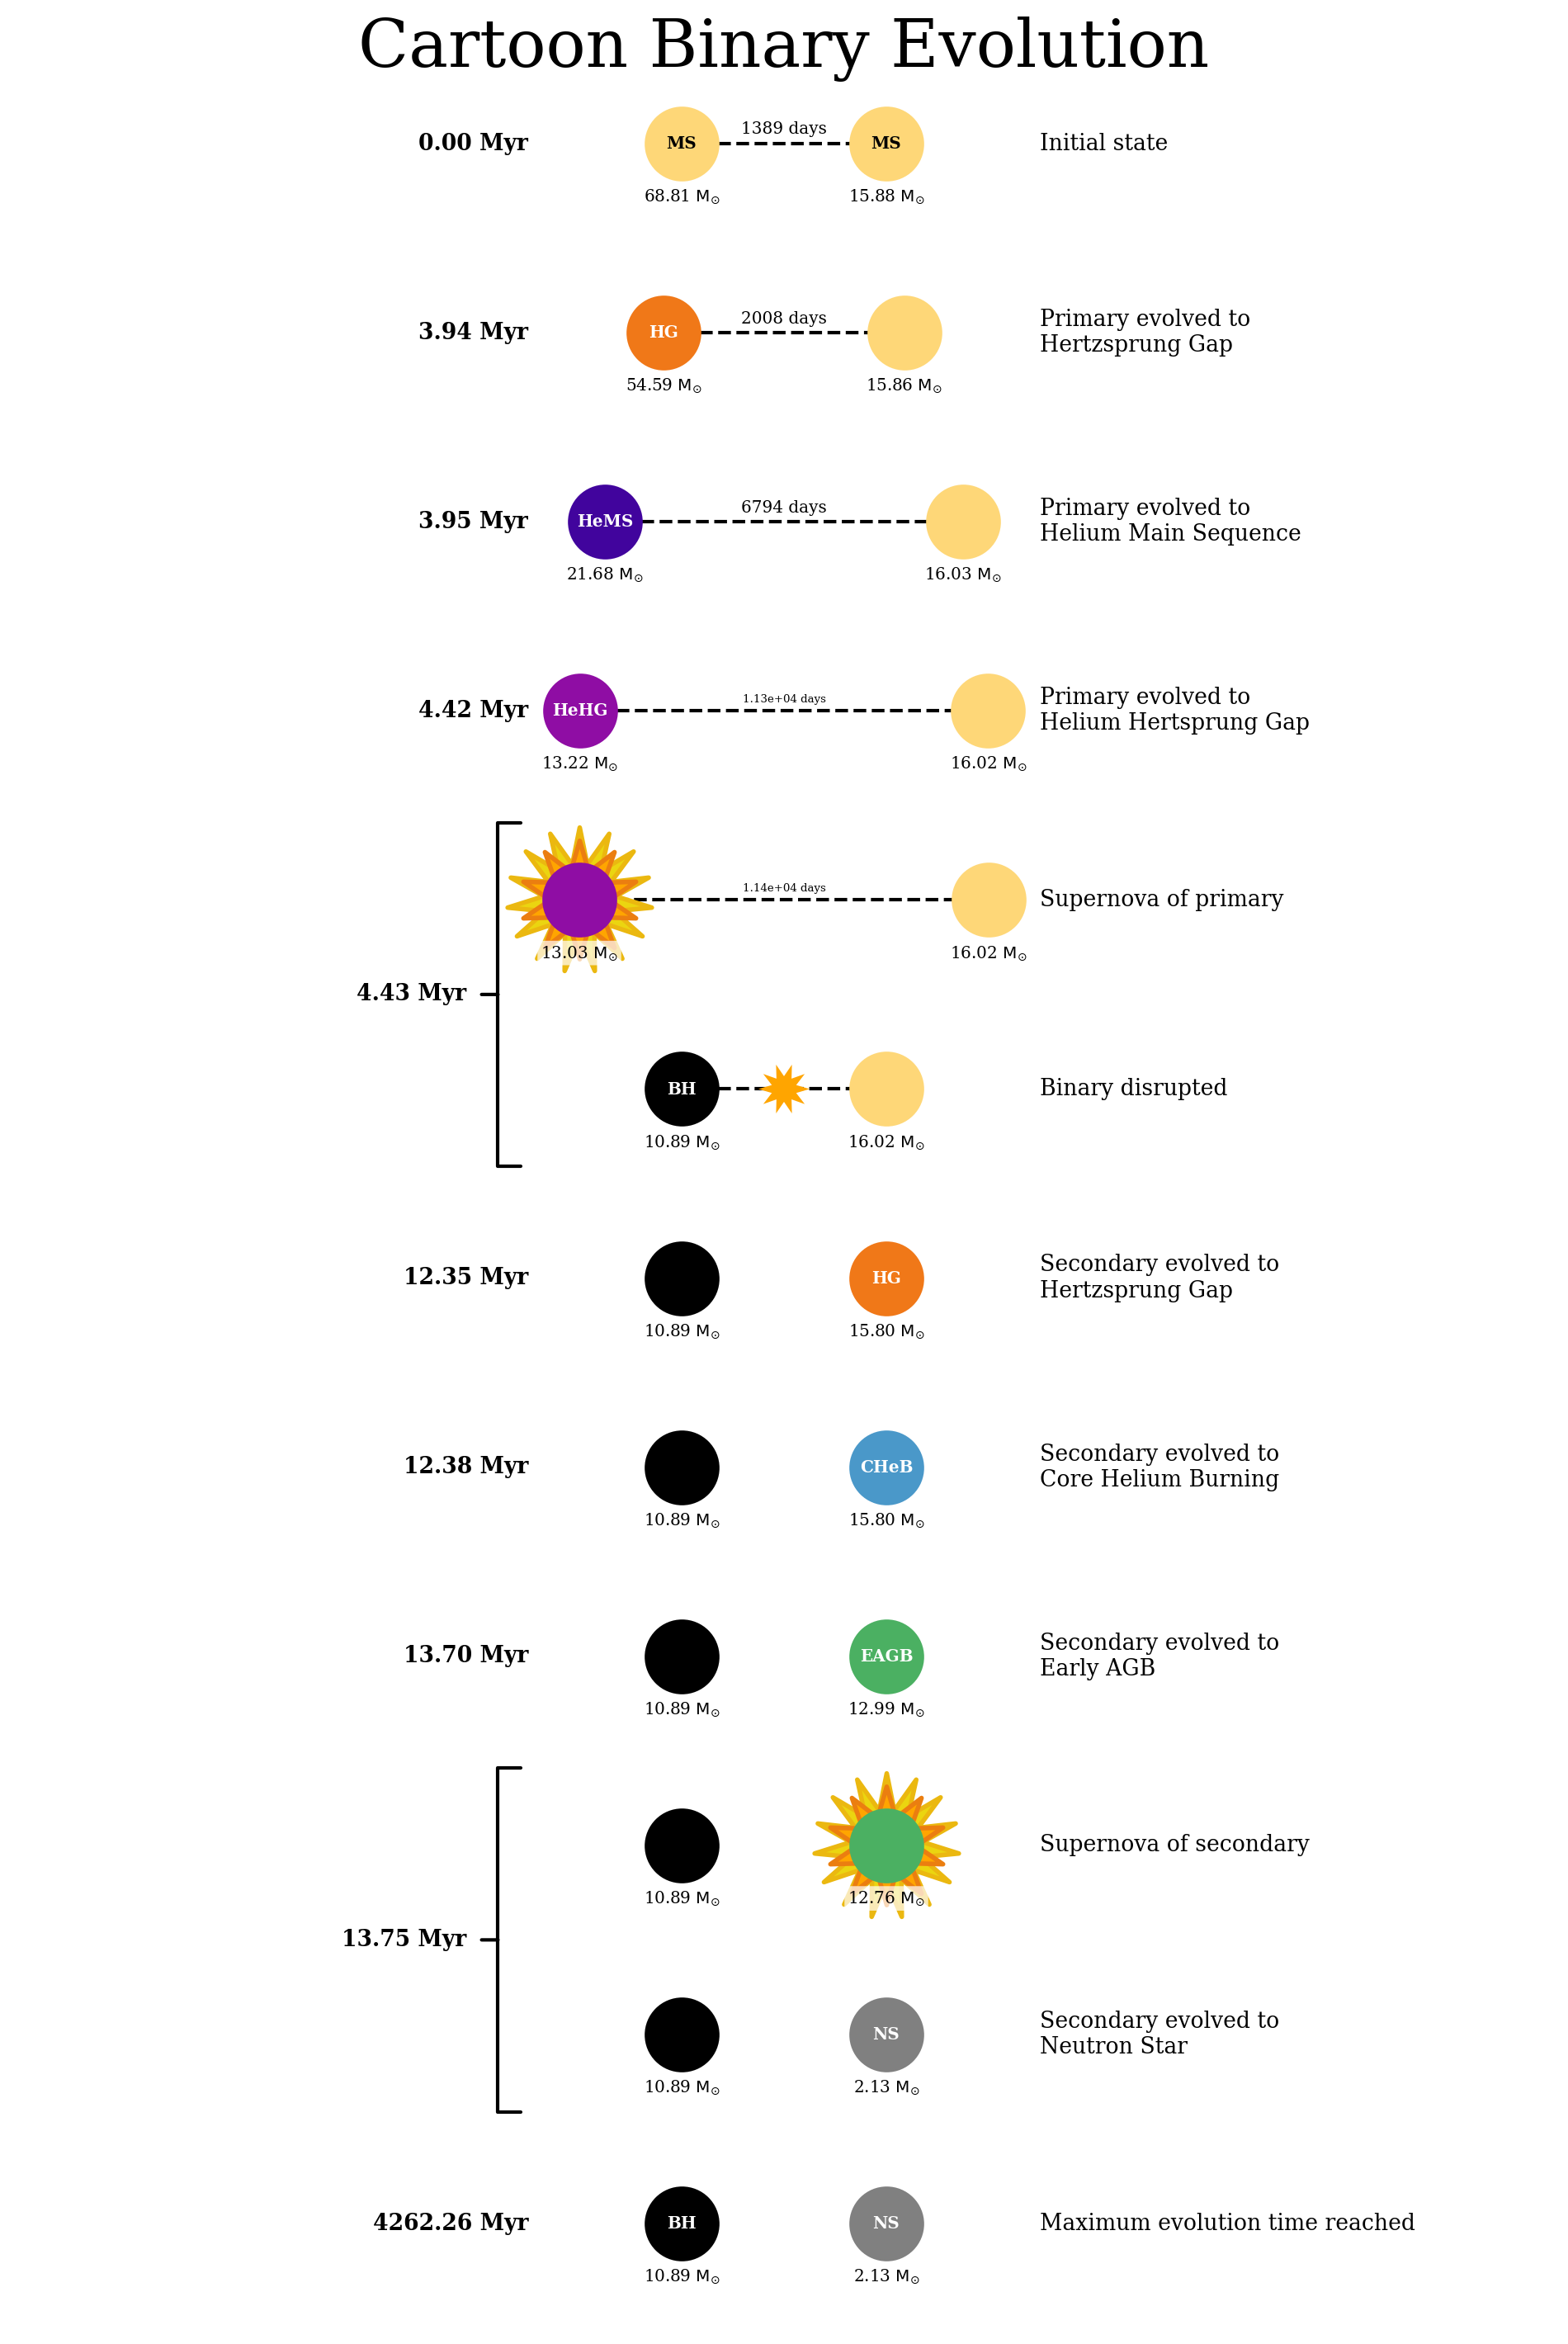

(<Figure size 1200x1800 with 1 Axes>, <Axes: >)

In [26]:
disrupted_binary = p.bin_nums[p.disrupted][1]

p.plot_cartoon_binary(disrupted_binary)

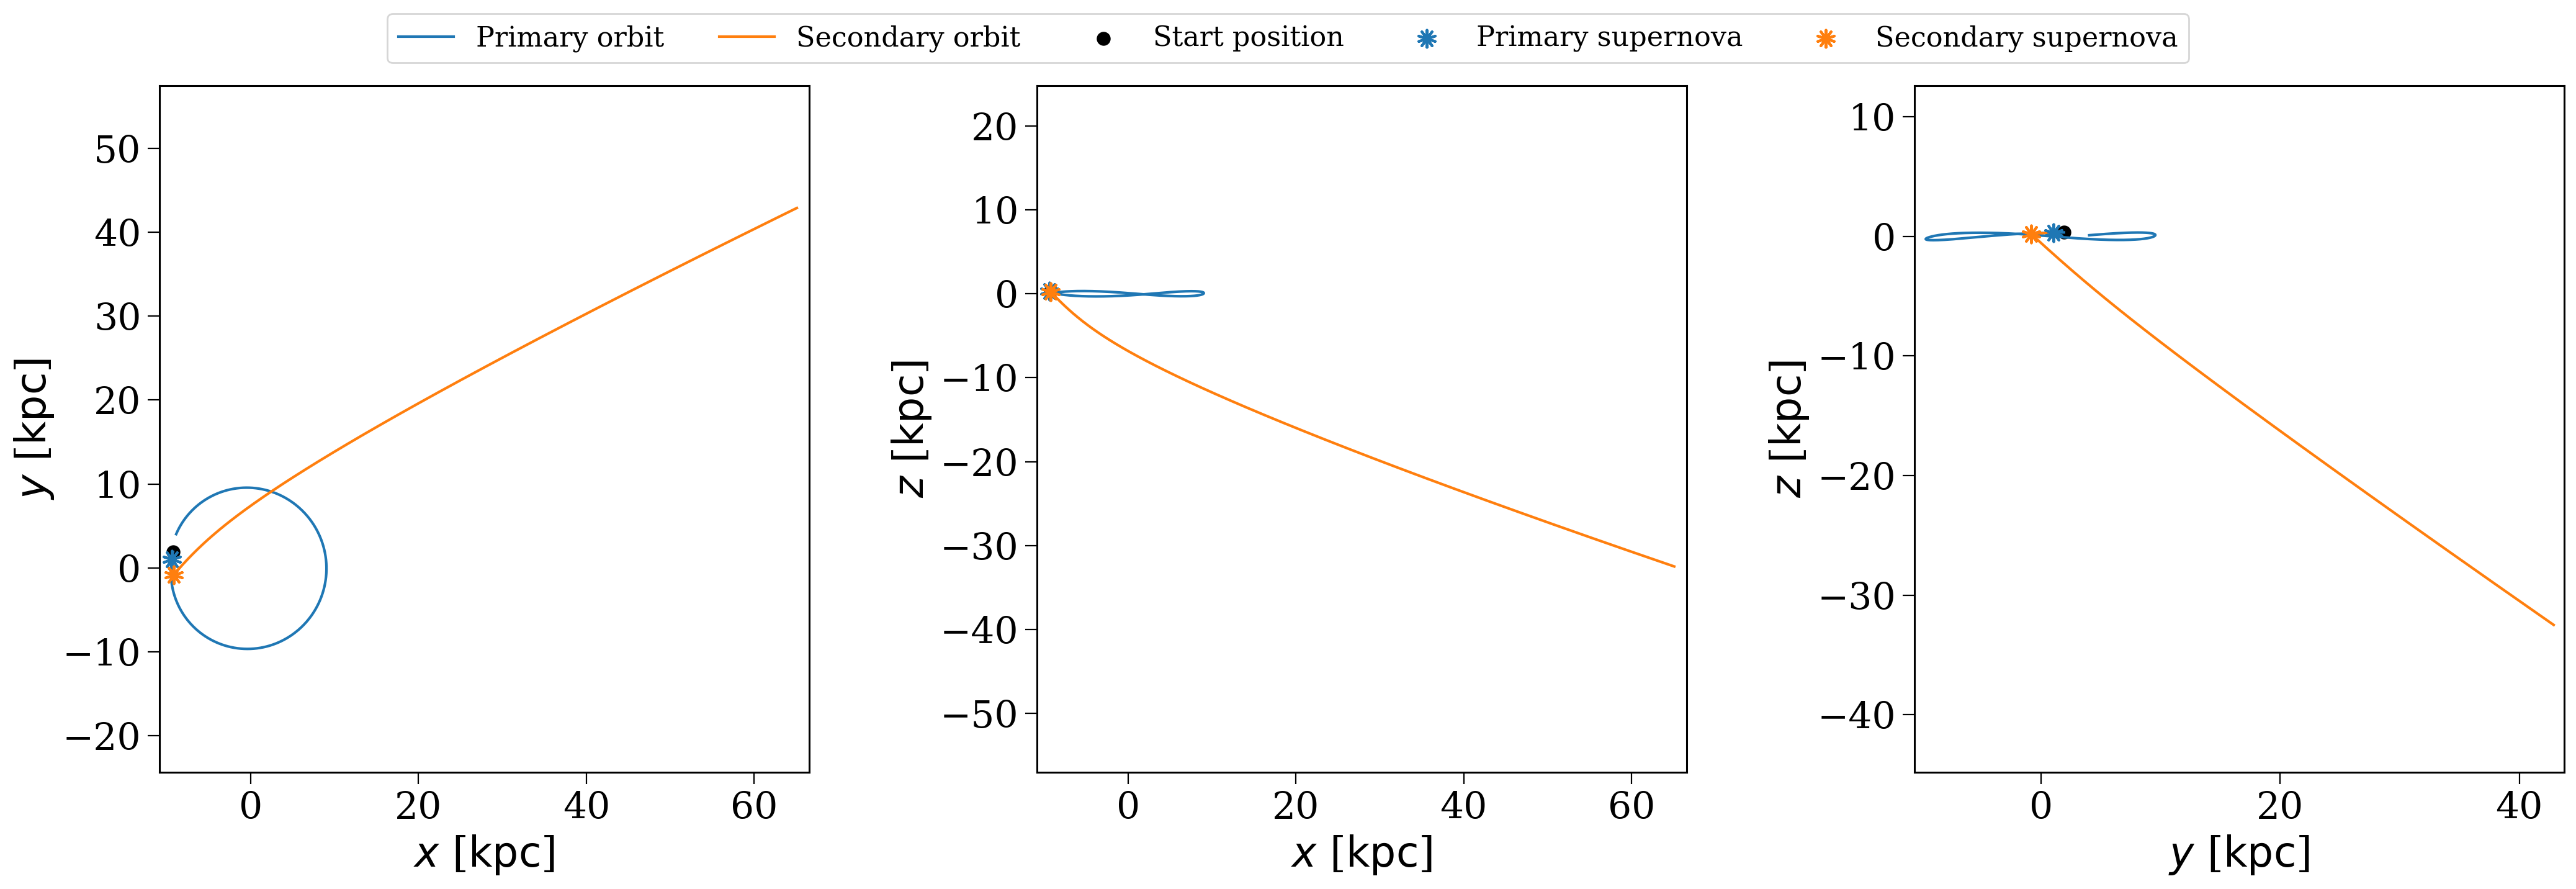

(<Figure size 2500x700 with 3 Axes>,
 [<Axes: xlabel='$x$ [$\\mathrm{kpc}$]', ylabel='$y$ [$\\mathrm{kpc}$]'>,
  <Axes: xlabel='$x$ [$\\mathrm{kpc}$]', ylabel='$z$ [$\\mathrm{kpc}$]'>,
  <Axes: xlabel='$y$ [$\\mathrm{kpc}$]', ylabel='$z$ [$\\mathrm{kpc}$]'>])

In [31]:
p.plot_orbit(disrupted_binary, t_max=250 * u.Myr)

In [3]:
@np.vectorize
def dm_mass_growth_at_tau(tau):
    if tau > 9:
        return (2.32 - (0.88 - 0.4) / 3 * tau)
    else:
        return (1 - 12 / 900 * tau)

def baryon_mass_growth_at_tau(tau):
    return 0.8 / 12 * (12 - tau) + 0.2

In [4]:
@np.vectorize
def dm_mass_growth_at_tau(tau):
    if tau > 9:
        return (2.32 - (0.88 - 0.4) / 3 * tau)
    else:
        return (1 - 12 / 900 * tau)

def baryon_mass_growth_at_tau(tau):
    return 0.8 / 12 * (12 - tau) + 0.2

static_mw = gp.MilkyWayPotential(version='v2')

time_knots = np.linspace(0, 12, 20) * u.Gyr
lookback_times = 12 * u.Gyr - time_knots

m_dm = dm_mass_growth_at_tau(lookback_times.to(u.Gyr).value) * static_mw["halo"].parameters["m"].value
m_bary = baryon_mass_growth_at_tau(lookback_times.to(u.Gyr).value) * (static_mw["disk"].parameters["m"].value)

evolving_dm = gp.CCompositePotential(
    disk=gp.MN3ExponentialDiskPotential(
        m=static_mw["disk"].parameters["m"],
        h_R=2.6 * u.kpc,
        h_z=0.3 * u.kpc,
        units="galactic"
    ),
    bulge=gp.HernquistPotential(
        m=5e9 * u.Msun,
        c=1.0 * u.kpc,
        units="galactic"
    ),
    nucleus=gp.HernquistPotential(
        m=1.81e9 * u.Msun,
        c=0.07 * u.kpc,
        units="galactic"
    ),
    halo=gp.TimeInterpolatedPotential(
        gp.NFWPotential,
        time_knots,
        m=m_dm,
        r_s=15.63 * u.kpc,
        units="galactic"
    )
)

evolving_disk = gp.CCompositePotential(
    disk=gp.TimeInterpolatedPotential(
        gp.MN3ExponentialDiskPotential,
        time_knots,
        m=m_bary,
        h_R=2.6 * u.kpc,
        h_z=0.3 * u.kpc,
        units="galactic"
    ),
    bulge=gp.HernquistPotential(
        m=5e9 * u.Msun,
        c=1.0 * u.kpc,
        units="galactic"
    ),
    nucleus=gp.HernquistPotential(
        m=1.81e9 * u.Msun,
        c=0.07 * u.kpc,
        units="galactic"
    ),
    halo=gp.NFWPotential(
        m=static_mw["halo"].parameters["m"],
        r_s=15.63 * u.kpc,
        units="galactic"
    )
)

evolving_both = gp.CCompositePotential(
    disk=gp.TimeInterpolatedPotential(
        gp.MN3ExponentialDiskPotential,
        time_knots,
        m=m_bary,
        h_R=2.6 * u.kpc,
        h_z=0.3 * u.kpc,
        units="galactic"
    ),
    bulge=gp.HernquistPotential(
        m=5e9 * u.Msun,
        c=1.0 * u.kpc,
        units="galactic"
    ),
    nucleus=gp.HernquistPotential(
        m=1.81e9 * u.Msun,
        c=0.07 * u.kpc,
        units="galactic"
    ),
    halo=gp.TimeInterpolatedPotential(
        gp.NFWPotential,
        time_knots,
        m=m_dm,
        r_s=15.63 * u.kpc,
        units="galactic"
    )
)

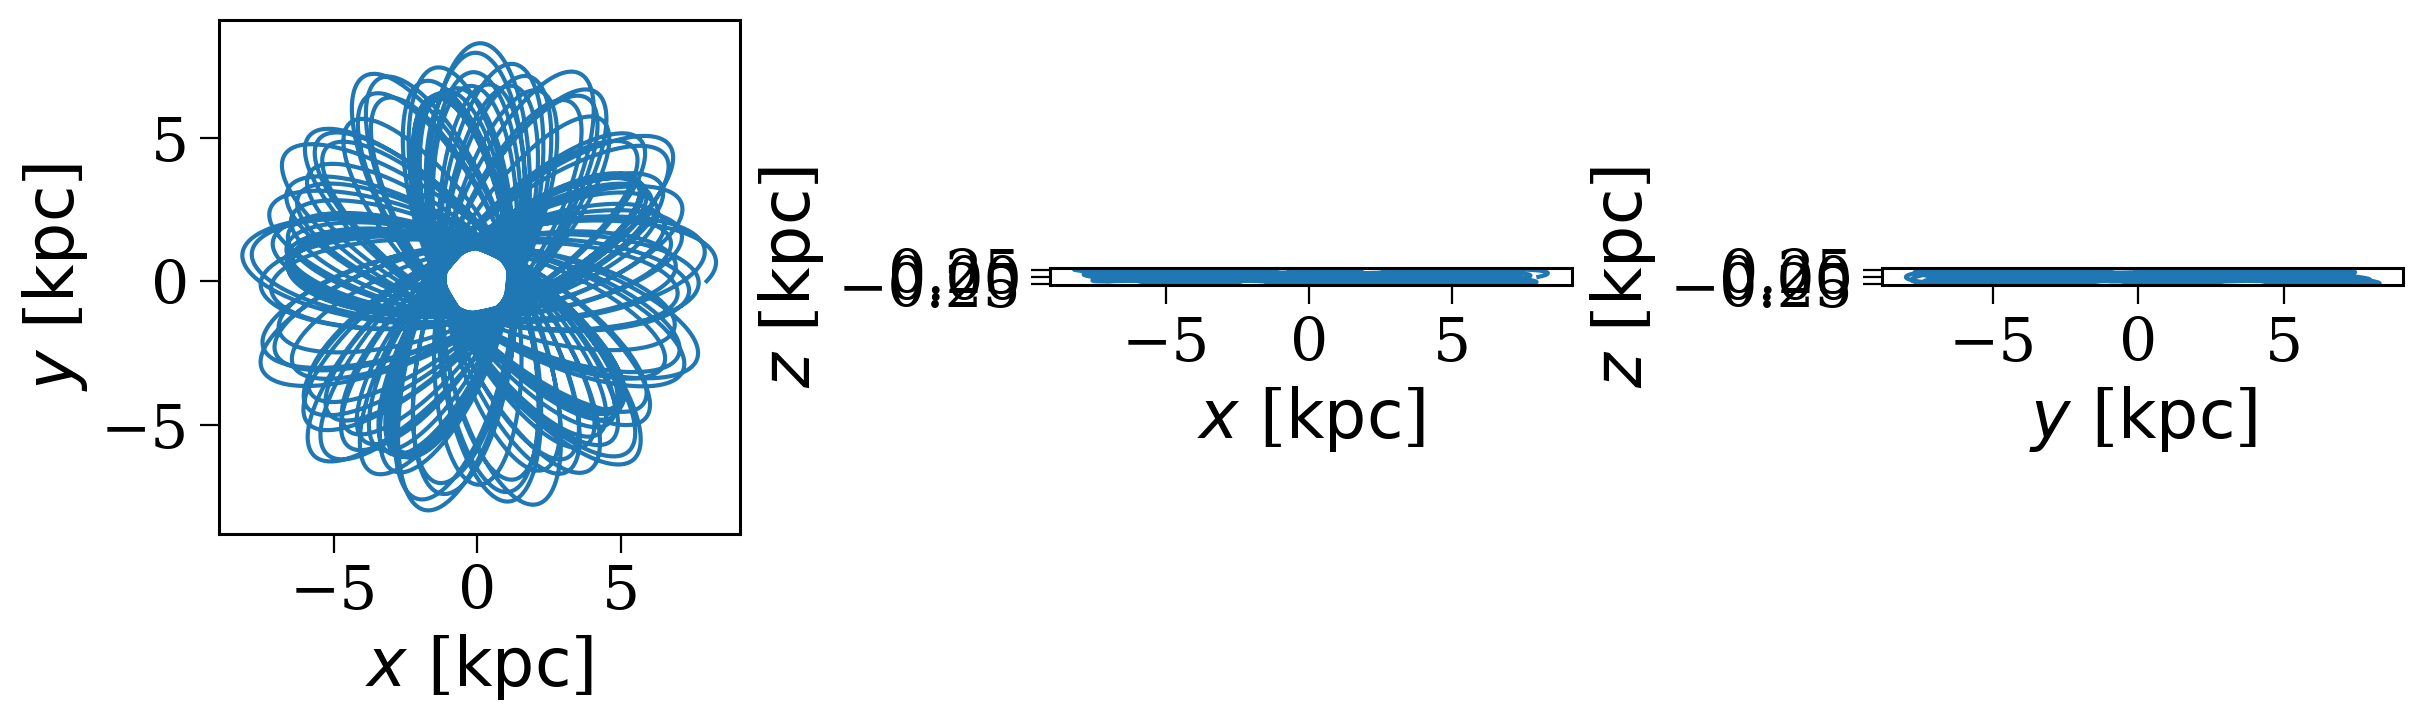

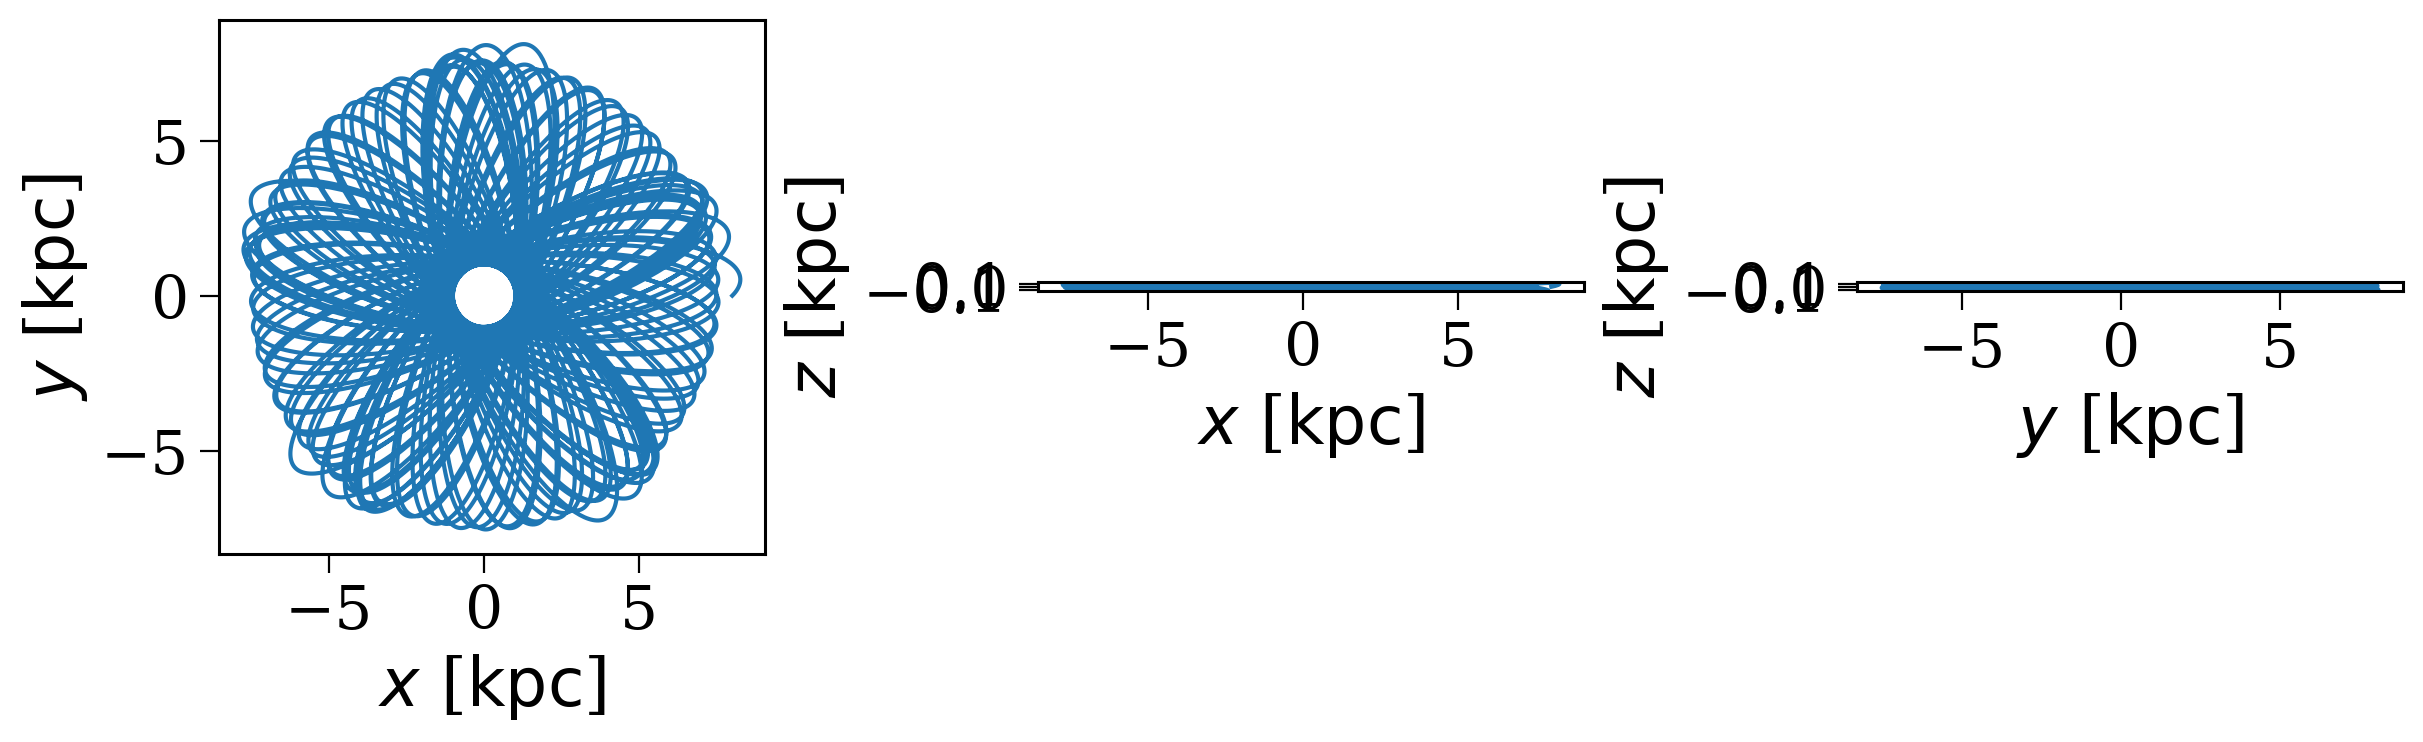

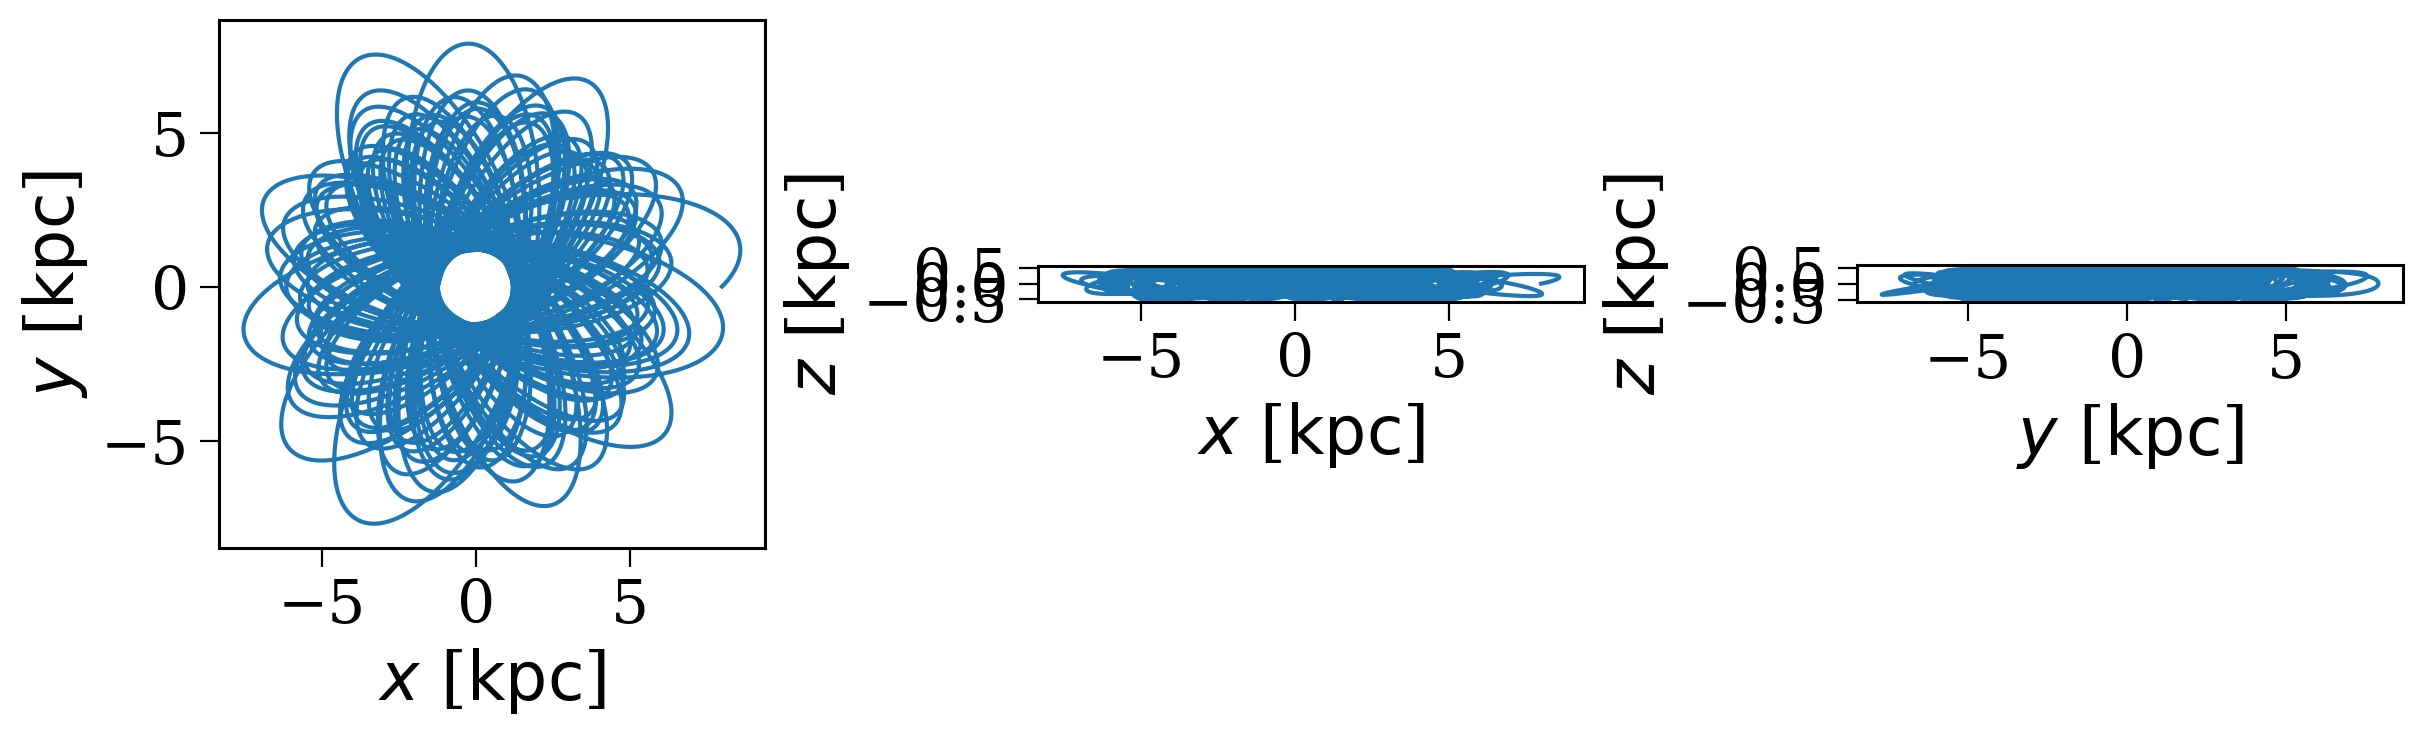

In [5]:
import gala.dynamics as gd

w0 = gd.PhaseSpacePosition(pos=[8., 0., 0.]*u.kpc, vel=[50., 50., 10.]*u.km/u.s)

for pot in [evolving_disk, evolving_dm, evolving_both]:
    pot.integrate_orbit(w0, t1=0*u.Gyr, t2=12*u.Gyr, dt=1*u.Myr).plot()

In [6]:
static_pop = cogsworth.pop.Population(
    100, final_kstar1=[14], use_default_BSE_settings=True,
    galactic_potential=static_mw
)
static_pop.create_population()

Run for 100 binaries
Sampled 104 binaries
[4e-02s] Sample initial binaries


[0.7s] Evolve binaries (run COSMIC)


Integrating orbits: 100%|██████████| 139/139 [00:00<00:00, 843.81it/s]


[0.4s] Integrate galactic orbits (run gala)
Overall: 1.2s


In [7]:
evolving_pops = []
for pot in [evolving_disk, evolving_dm, evolving_both]:
    evolving_pop = static_pop.copy()
    evolving_pop.galactic_potential = pot
    evolving_pop.perform_galactic_evolution()
    evolving_pops.append(evolving_pop)

Integrating orbits:   0%|          | 0/139 [00:00<?, ?it/s]

Integrating orbits: 100%|██████████| 139/139 [00:00<00:00, 585.06it/s]


In [8]:
# find where the difference is non-zero
diff = evolving_pops[1].final_pos - evolving_pops[2].final_pos
diff_nonzero = np.where(np.any(diff != 0, axis=1))[0]
diff_nonzero

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138])

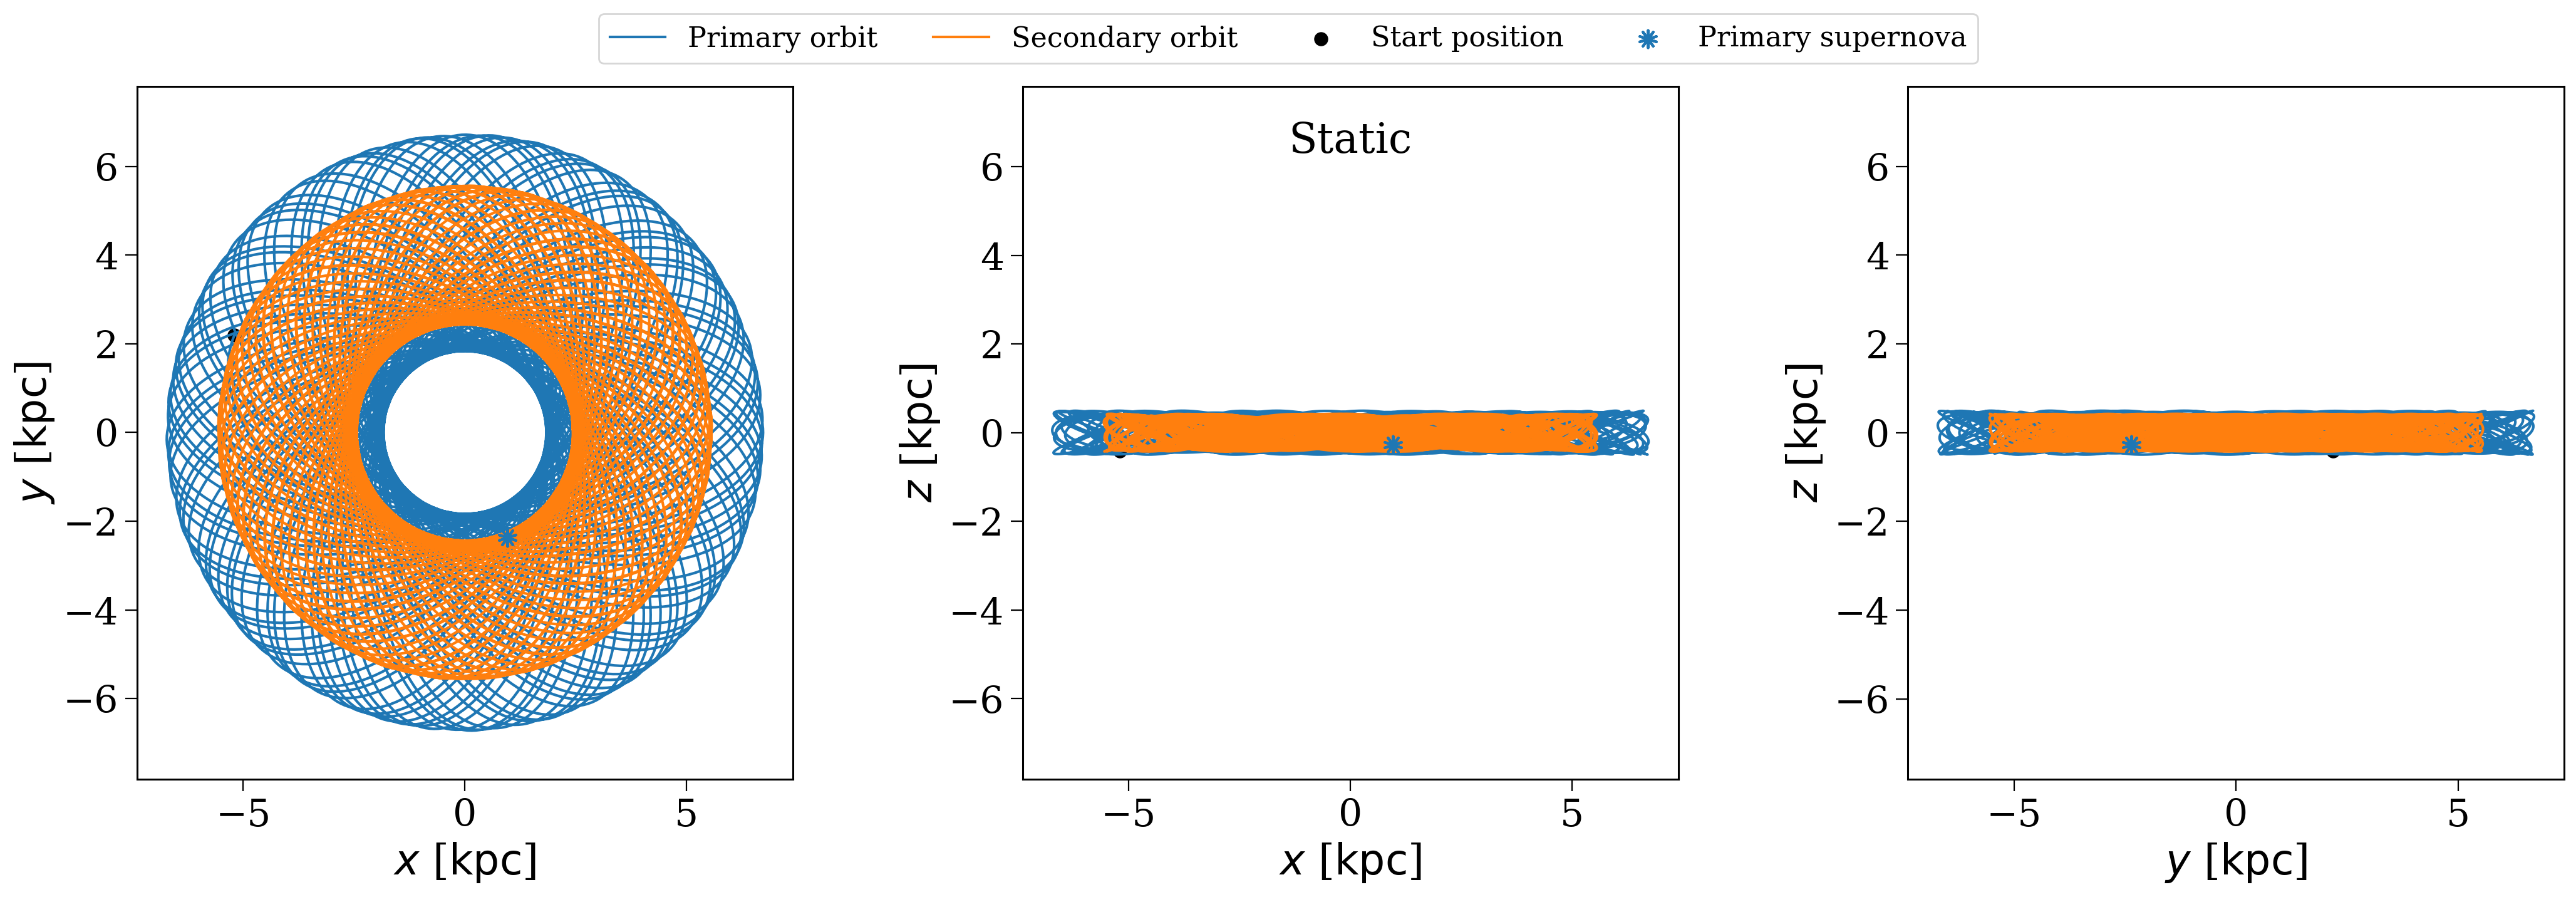

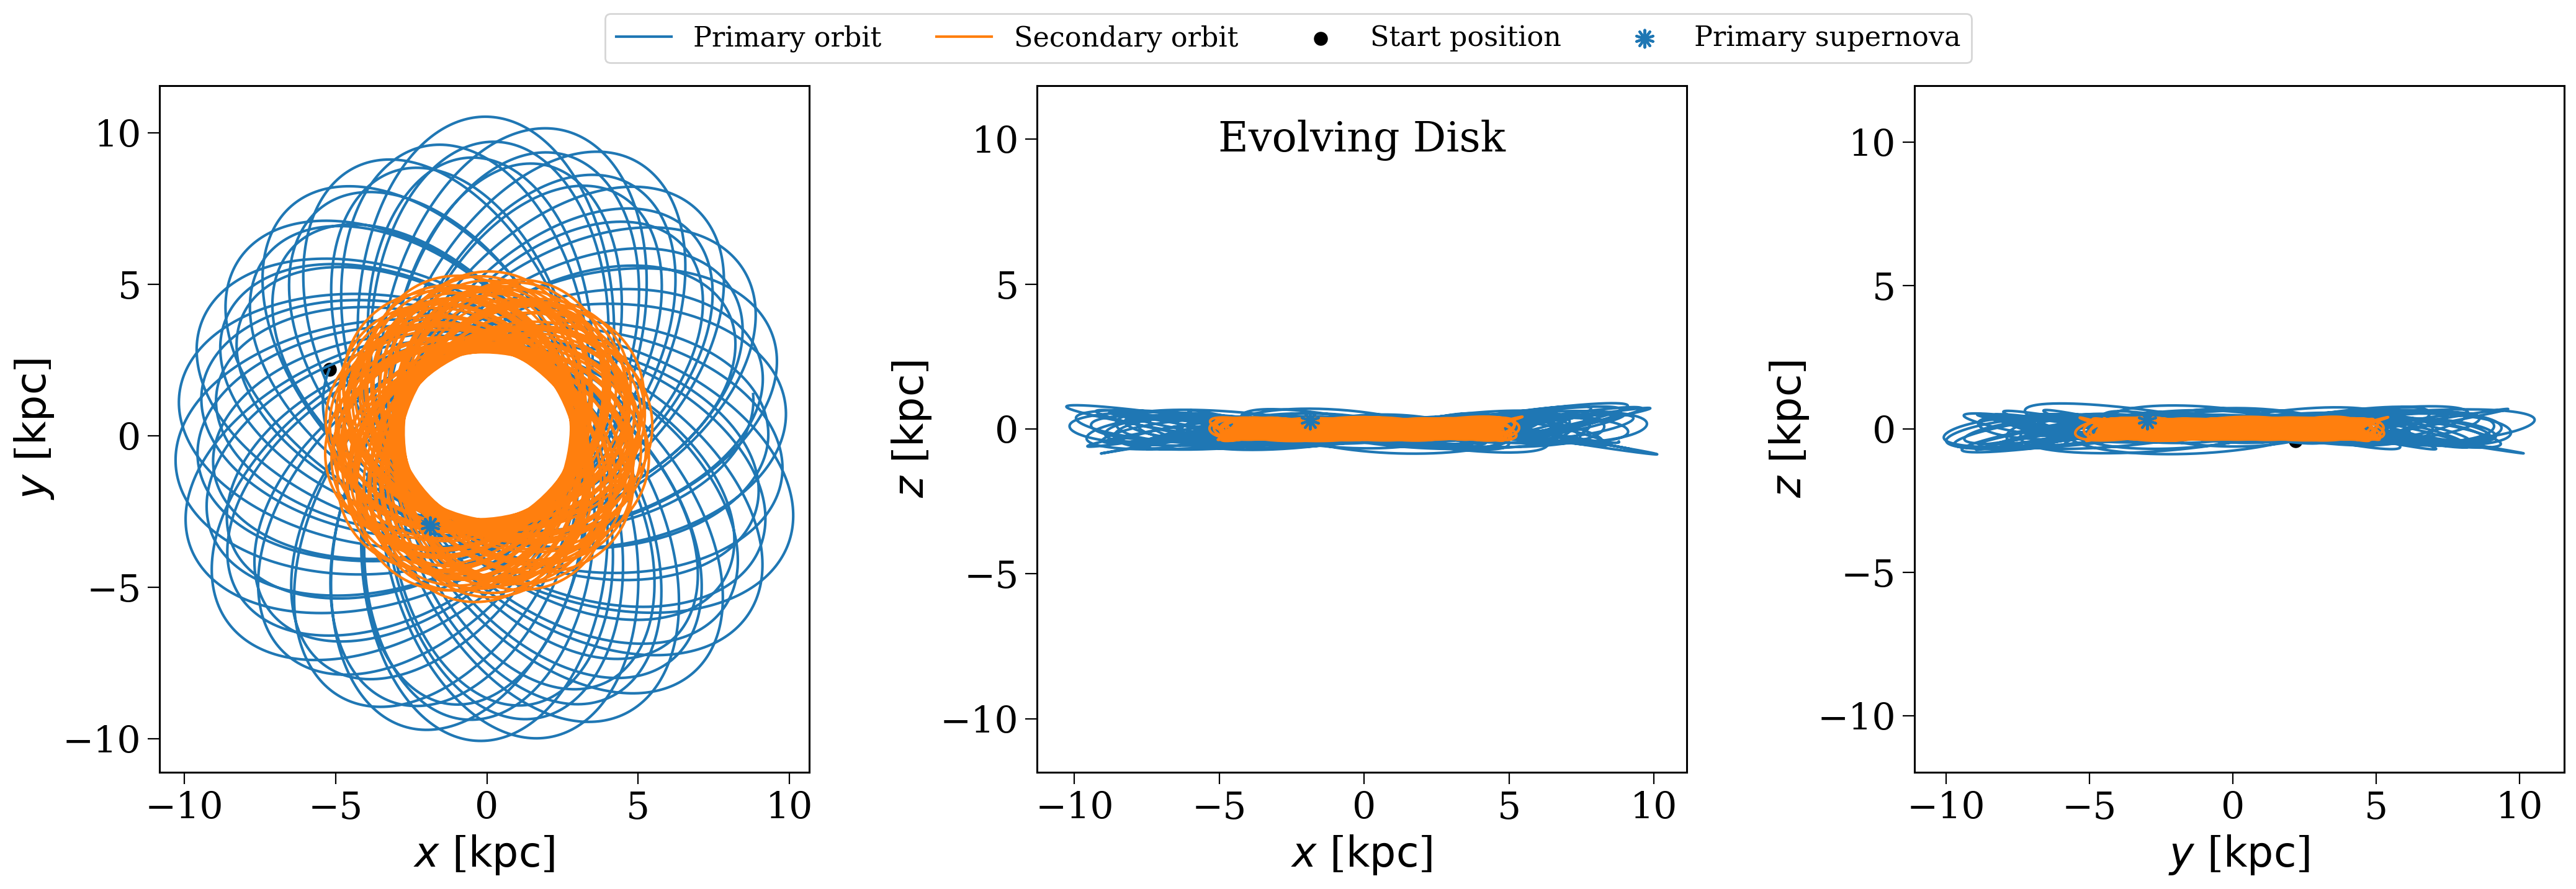

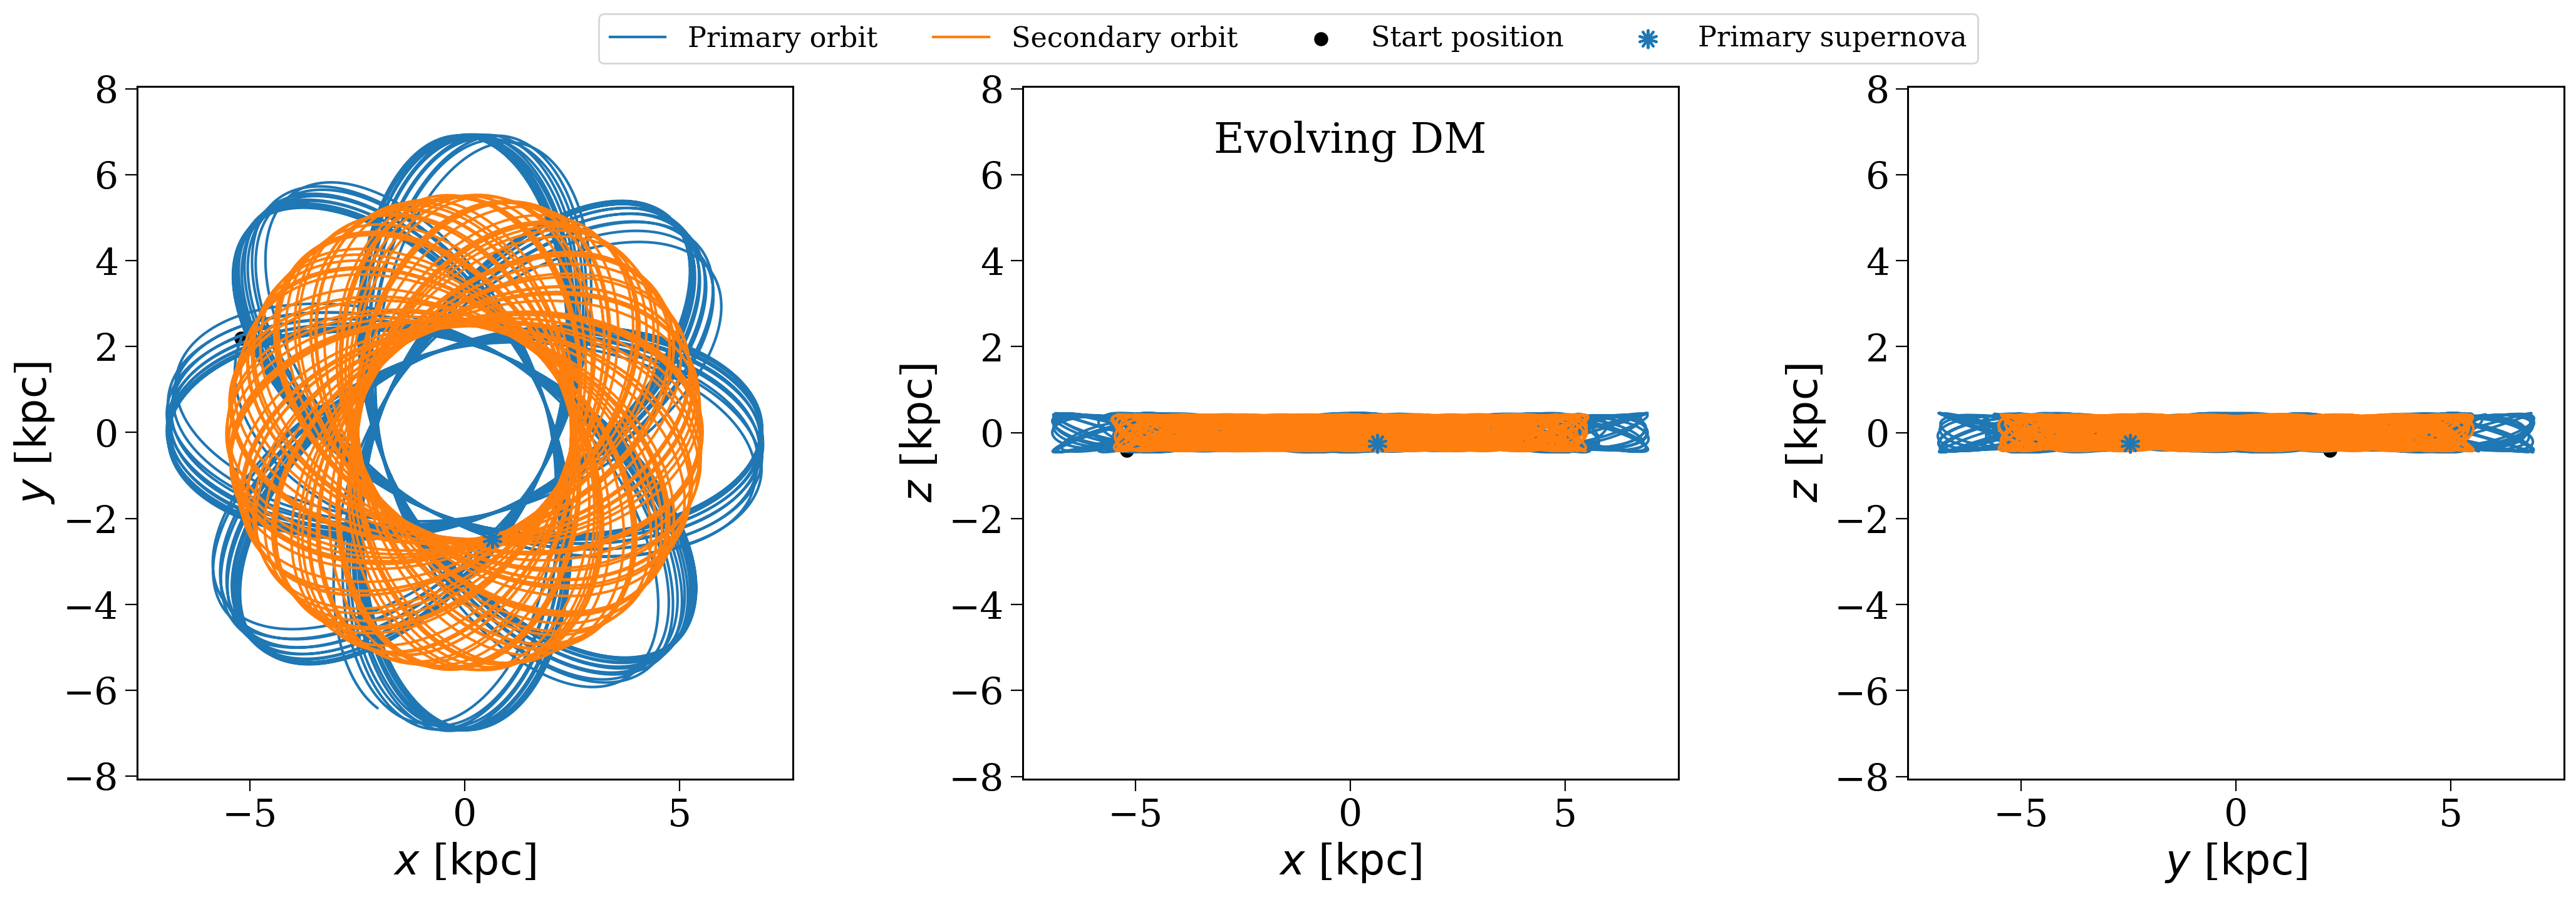

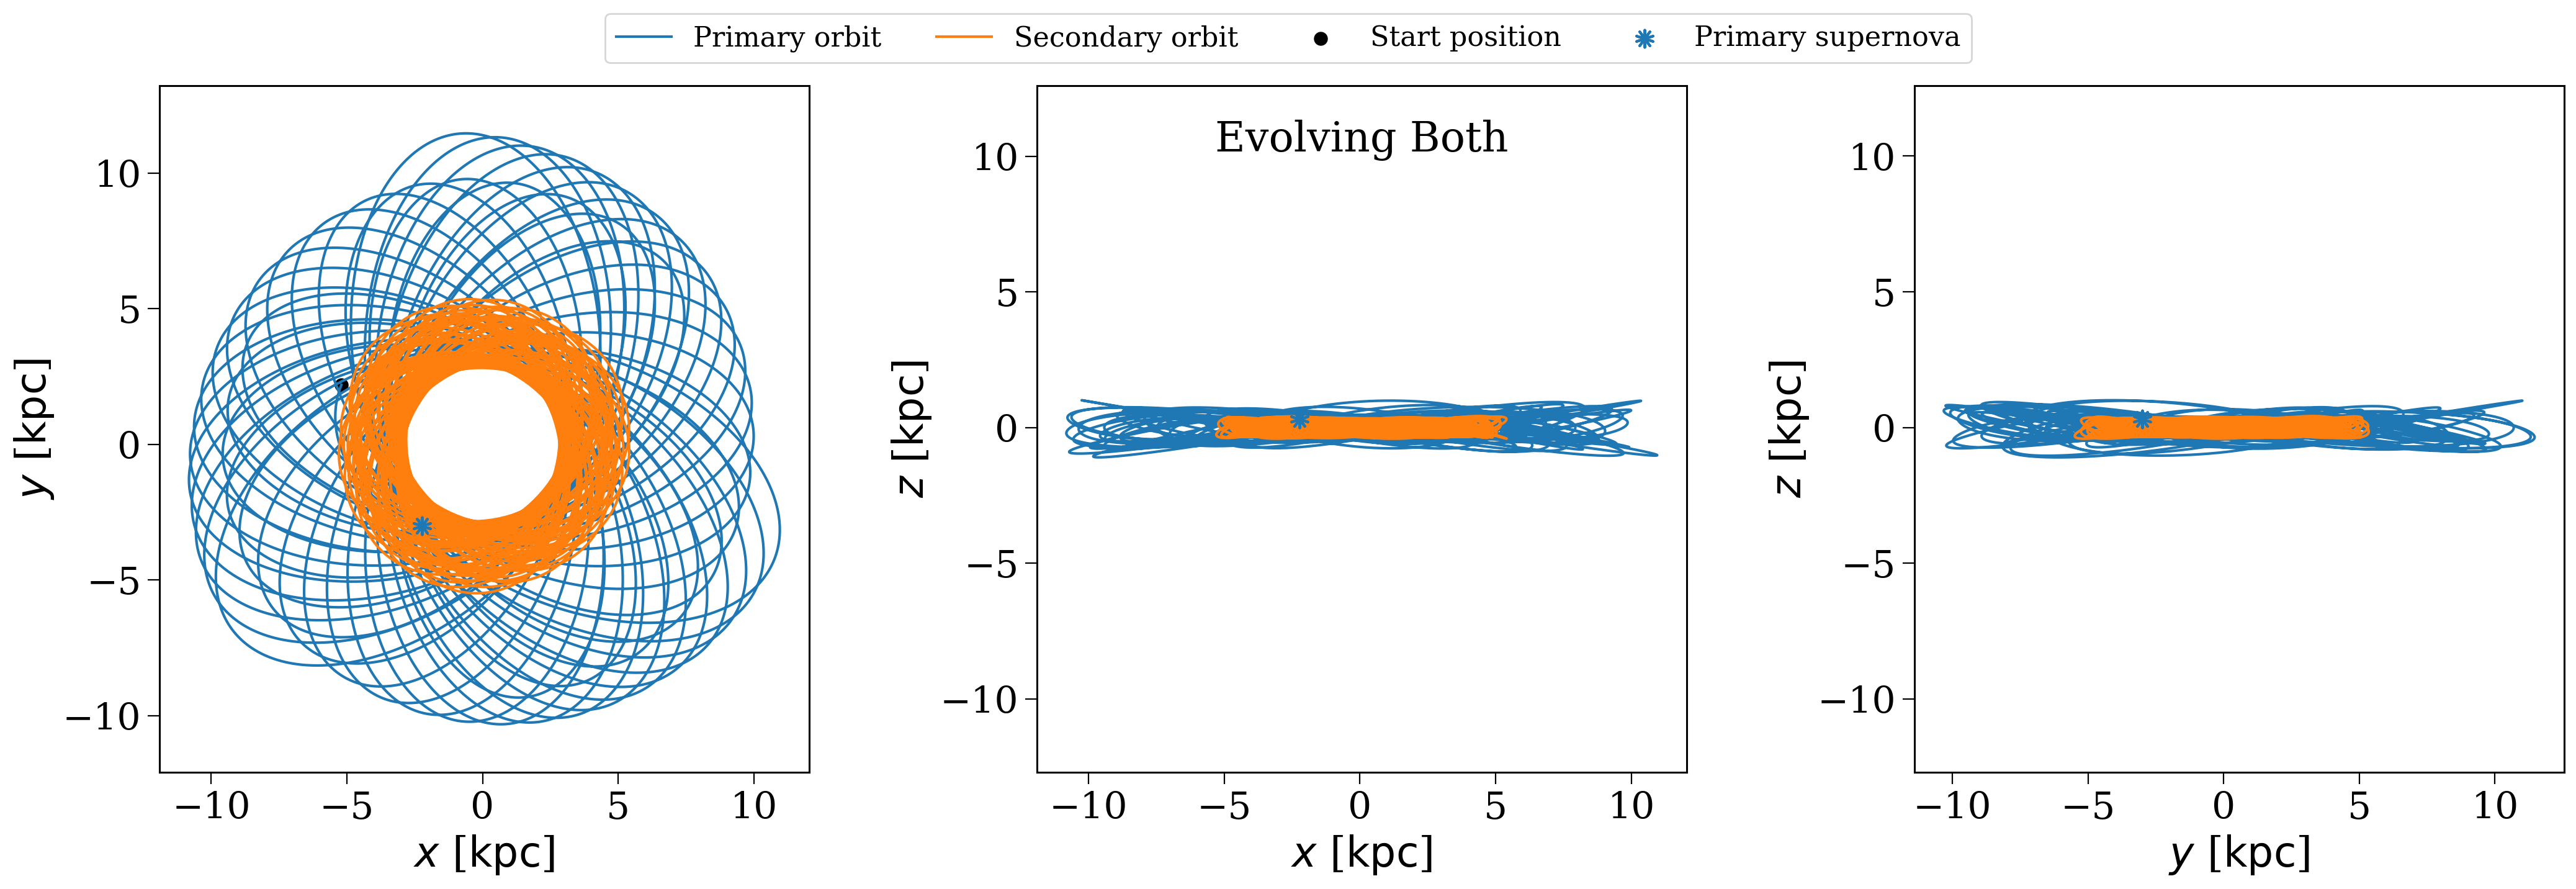

In [12]:
BIN_NUM = static_pop.bin_nums[static_pop.disrupted][1]

for pop, label in zip([static_pop] + evolving_pops, ["Static", "Evolving Disk", "Evolving DM", "Evolving Both"]):
    fig, axes = pop.plot_orbit(BIN_NUM, show=False)
    axes[1].annotate(label, xy=(0.5, 0.95), xycoords='axes fraction', ha='center', va='top', fontsize=fs)
    plt.show()

# Compare variation

In [5]:
reload(constants)
files = ["fiducial", "time-evolving-pot"]
labels = ["Static", "Time-evolving"]
colours = [constants.FILE_TO_COLOUR[f] for f in files]

In [6]:
pops, data = helpers.load_postprocessed_pops(
    [f"/mnt/ceph/users/twagg/underworld/postprocessed/{file}" for file in files],
    labels, colours
)

In [7]:
print("Escaped fractions:")
for pop in pops:
    escaped = data[pop.label]["escaped"]["CO"]
    frac = escaped.sum() / len(escaped)
    print(f'  - {pop.label}:')
    print(f'      - CO = {data[pop.label]["escaped"]["CO"].sum() / len(data[pop.label]["escaped"]["CO"]):1.3f}')
    print(f'      - BH = {data[pop.label]["escaped"]["BH"].sum() / len(data[pop.label]["escaped"]["BH"]):1.3f}')
    print(f'      - NS = {data[pop.label]["escaped"]["NS"].sum() / len(data[pop.label]["escaped"]["NS"]):1.3f}')

Escaped fractions:
  - Static:
      - CO = 0.106
      - BH = 0.029
      - NS = 0.135
  - Time-evolving:
      - CO = 0.192
      - BH = 0.066
      - NS = 0.240


Inner 10 kpc
  Static fraction within 0.5 kpc 0.48
  Time-evolving fraction within 0.5 kpc 0.25
Full population
  Static fraction within 0.5 kpc 0.39
  Time-evolving fraction within 0.5 kpc 0.16


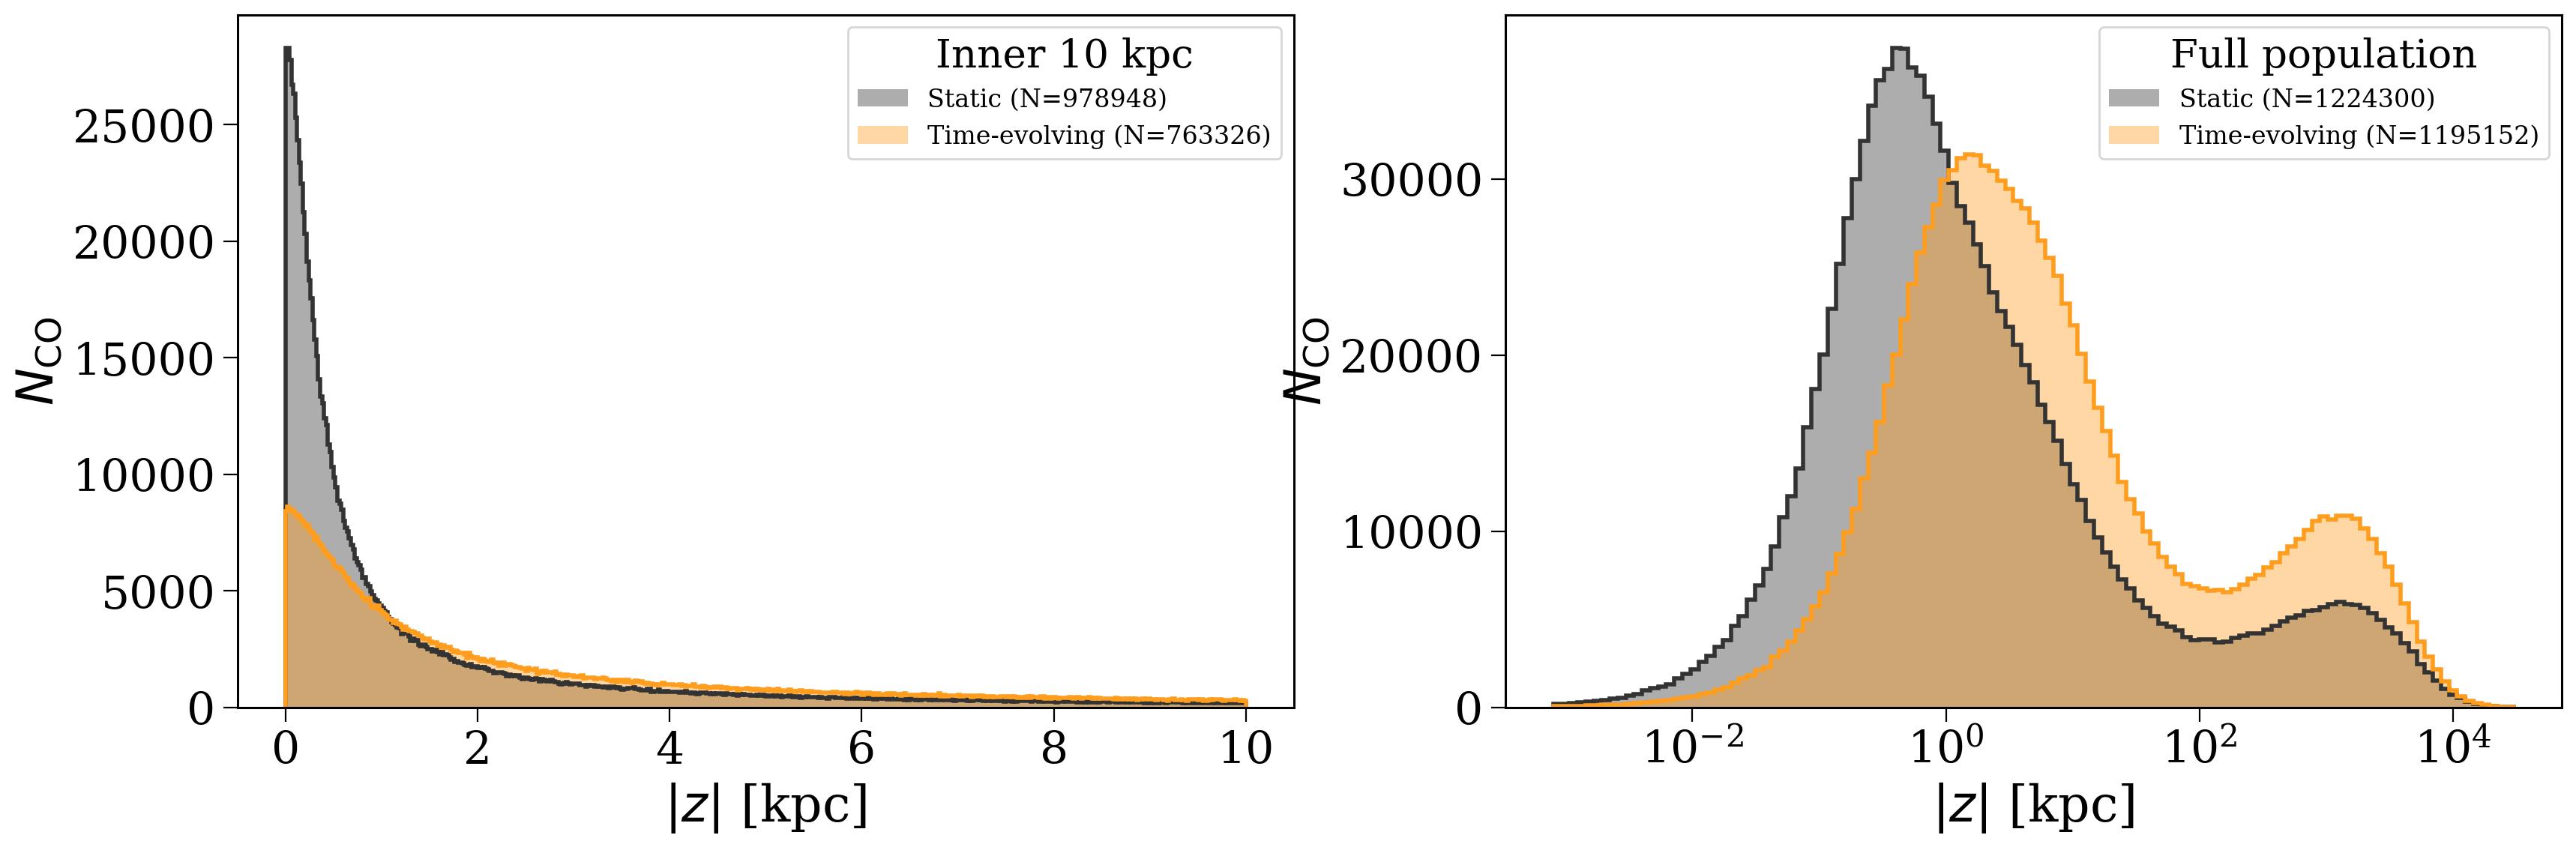

(<Figure size 2000x600 with 2 Axes>,
 array([<Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>,
        <Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>], dtype=object))

In [8]:
reload(plotting)
plotting.absolute_galactocentric_height(pops, data)

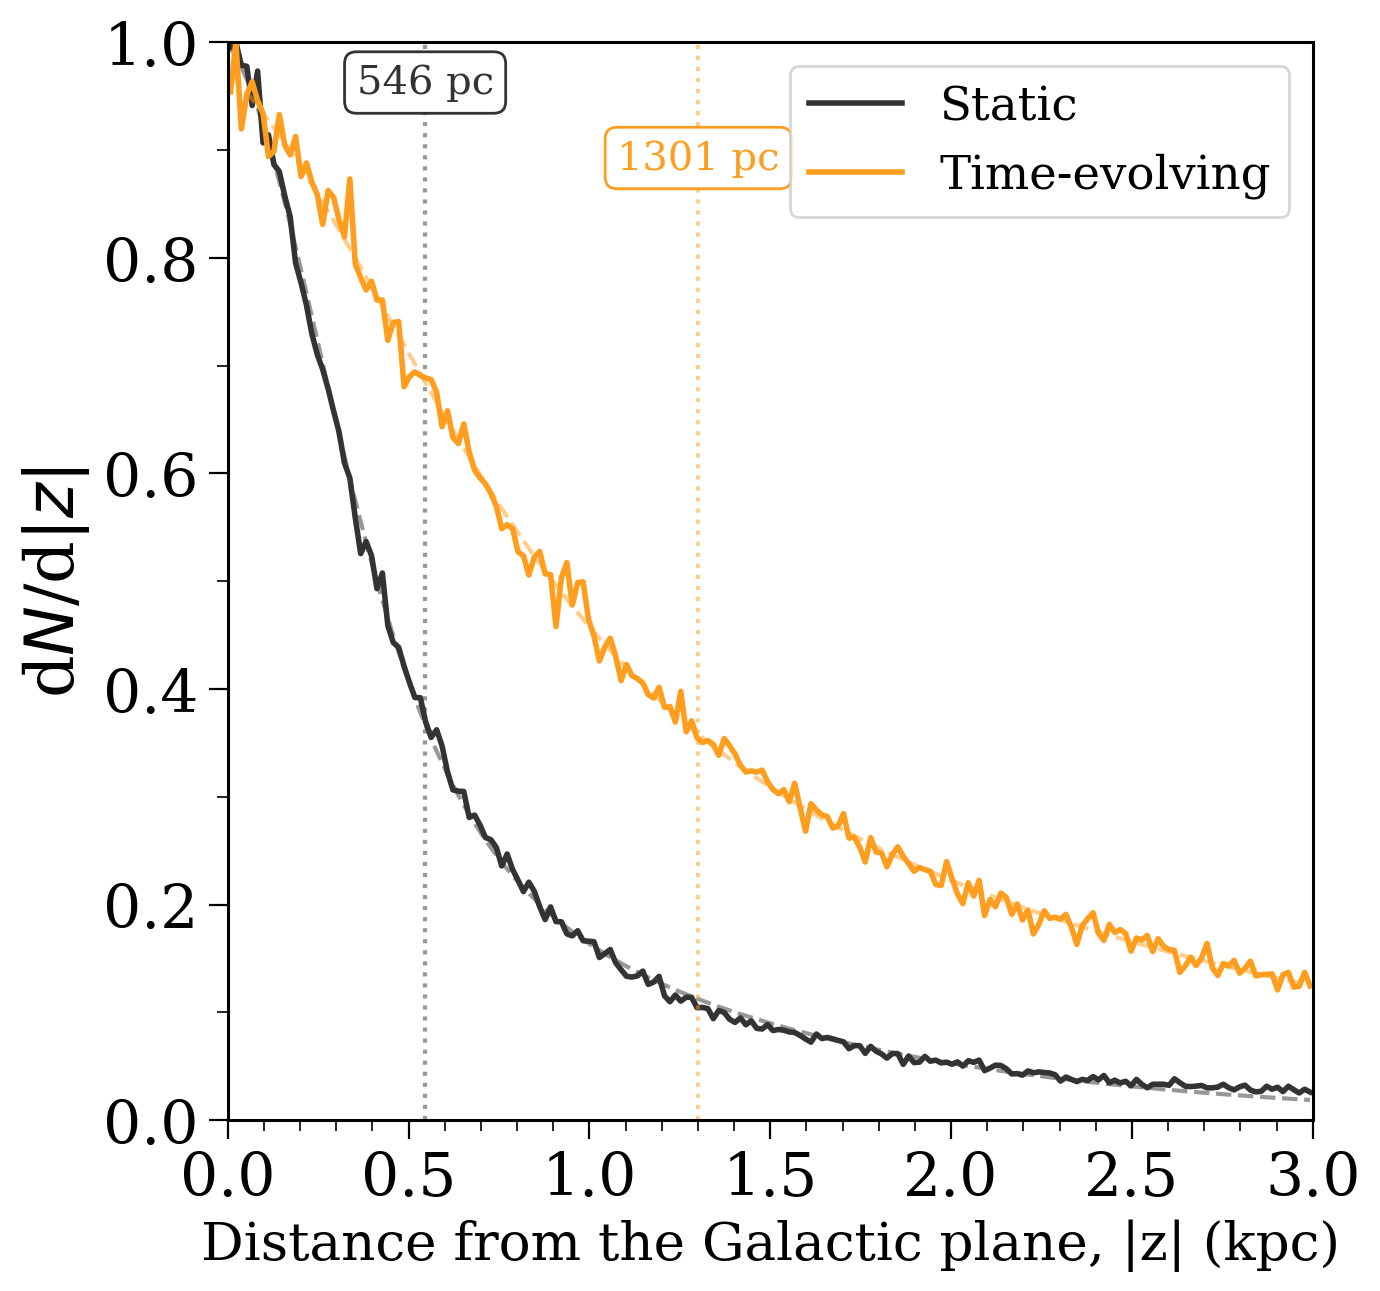

In [27]:
reload(plotting)

fig, ax = plt.subplots(figsize=(7, 7))


for i, pop in enumerate(pops):
    sh = plotting.estimate_scale_height(
        z=data[pop.label]["pos"]["BH"][:, 2],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_loc=0.98 - i * 0.07,
        R=None,
    )[0]

# add minor ticks every 0.1 kpc
ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_time_evolving.pdf", format="pdf", bbox_inches='tight')
plt.show()

9 12 2.8132434905581896
6 9 2.5160365920864103
3 6 2.222995649471722
0 0.1 1.5970445125247792
0 12 2.3704027065371602


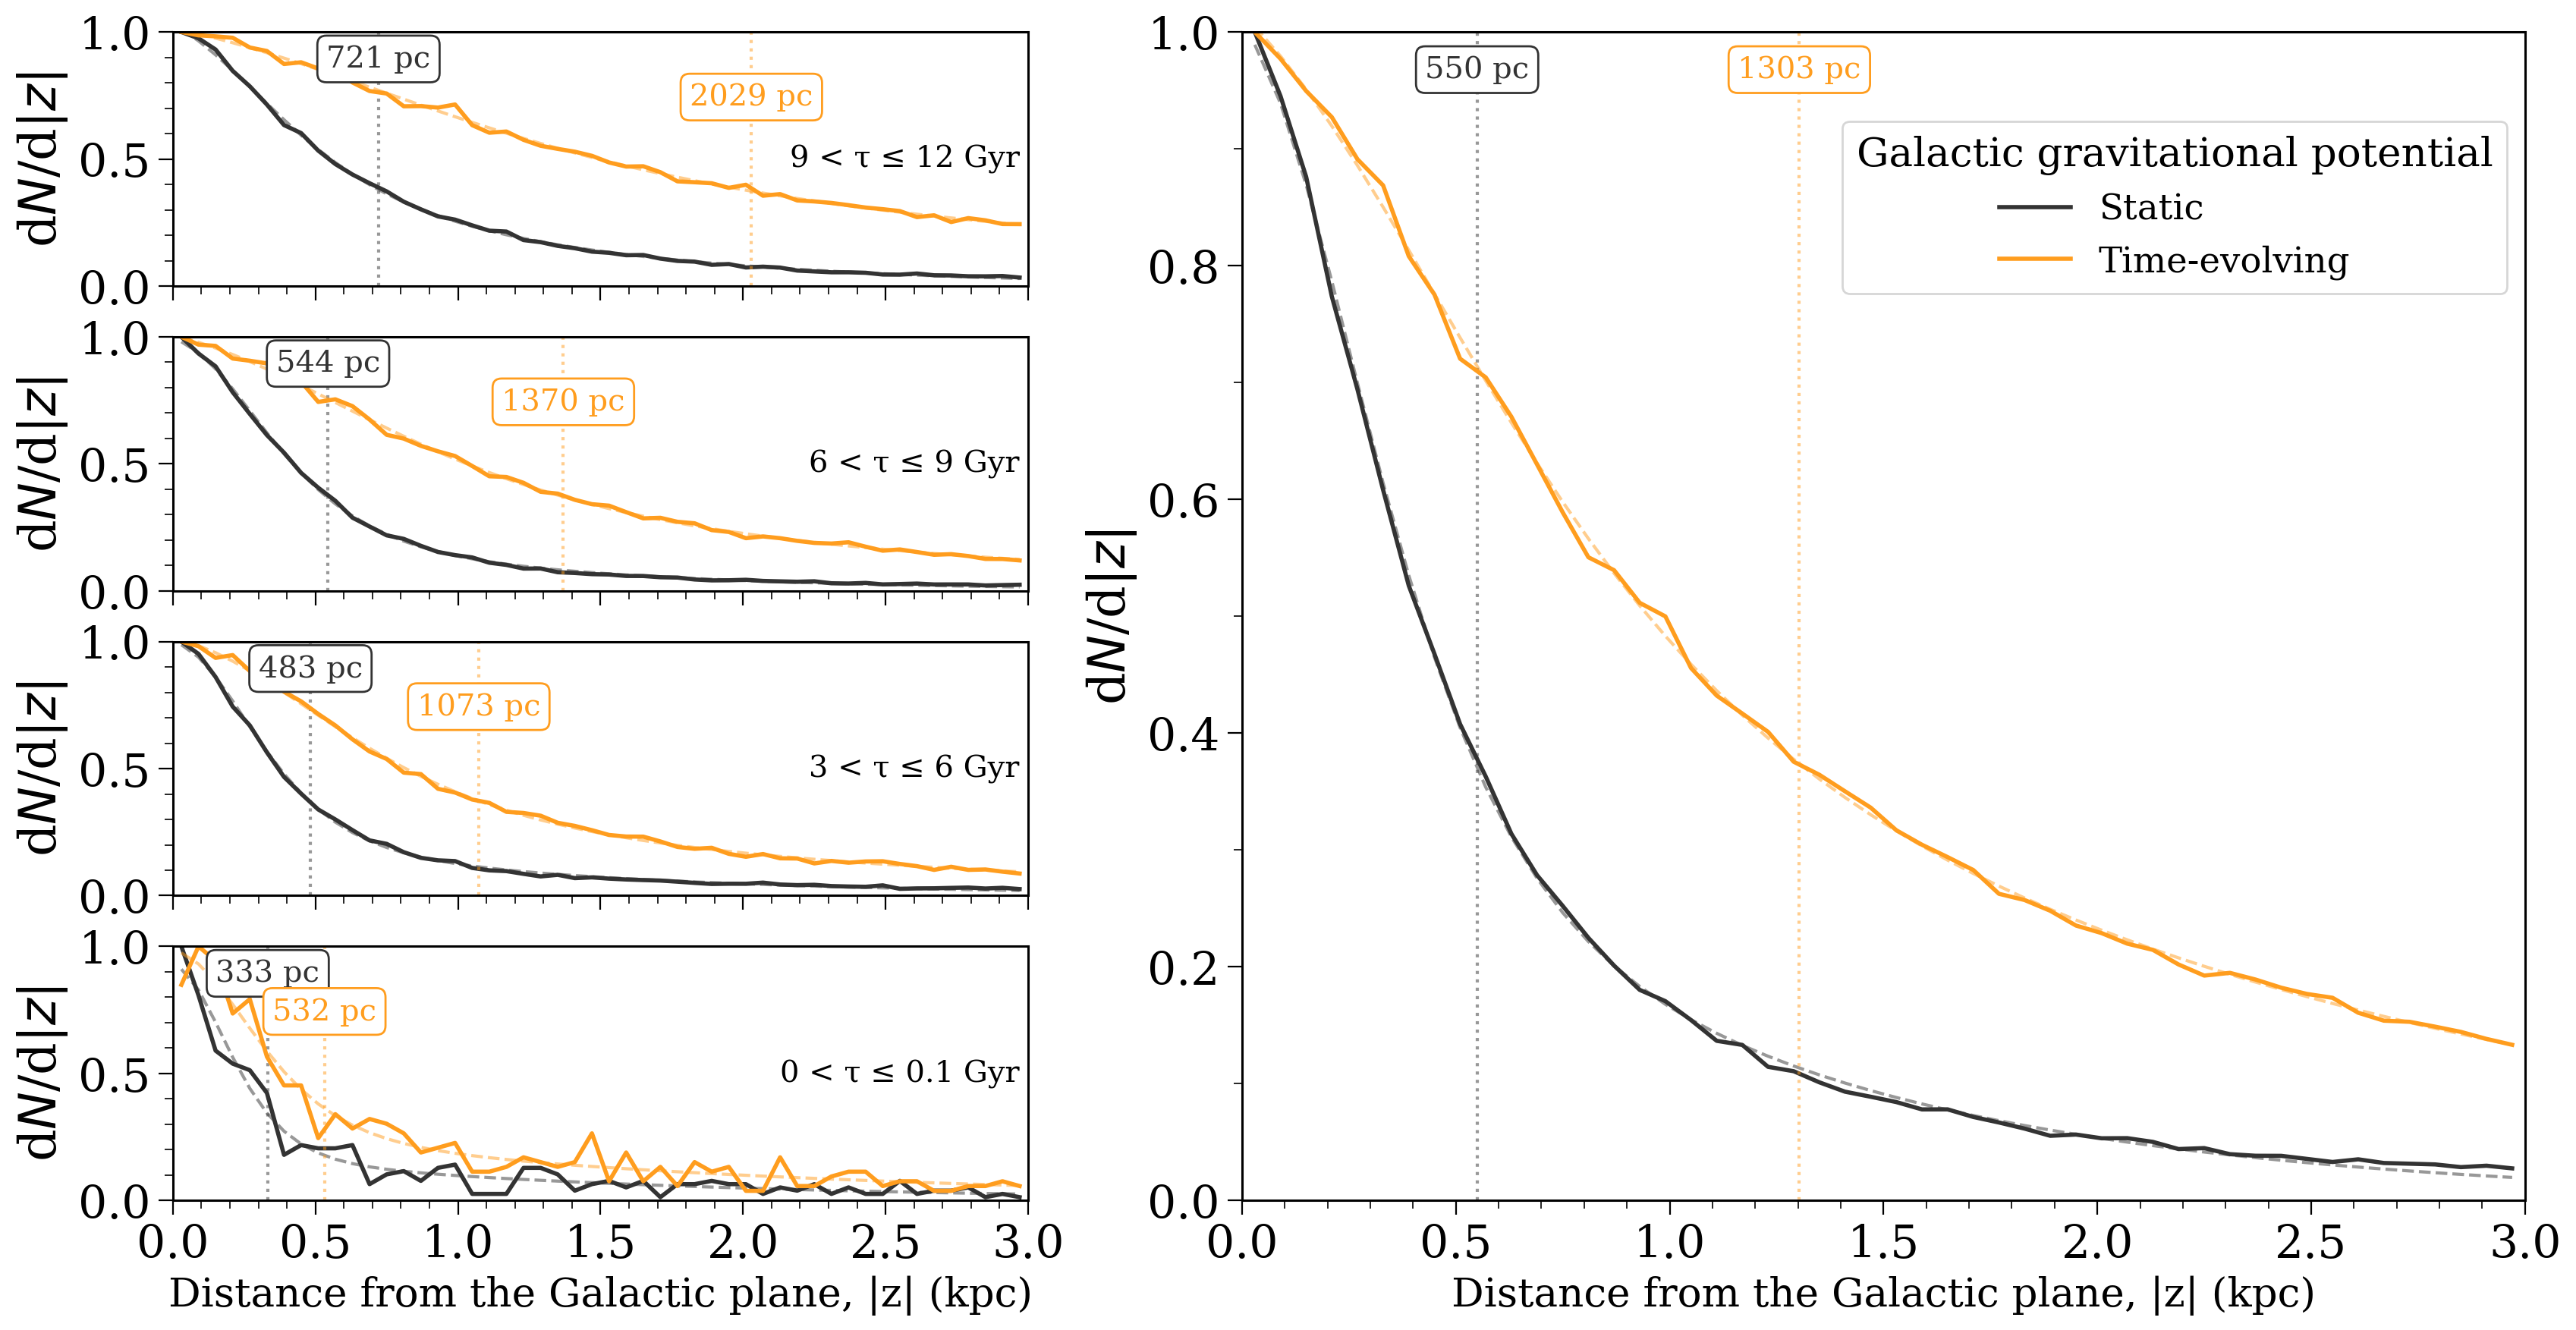

In [74]:
reload(plotting)

tau_lims = [(i, i + 2) for i in range(0, 12, 2)]
tau_lims = [(i, i + 3) for i in range(0, 12, 3)]
tau_lims = [(0, 12)] + tau_lims
tau_lims[1] = [0, 0.1]

fig = plt.figure(figsize=(20, 10))
layout = [
    [0, 4],
    [1, 4],
    [2, 4],
    [3, 4],
]
axes = fig.subplot_mosaic(layout, width_ratios=[1, 1.5])

# for tau_min, tau_max, tau_label in zip([0, 9, 0], [12, 12, 9], ["All", "Old", "Young"]):
for ax_ind, (tau_min, tau_max) in enumerate(reversed(tau_lims)):

    scale_heights = []
    for i, pop in enumerate(pops):
        tau = data[pop.label]["tau"]["BH"]
        mask = (tau > tau_min) & (tau <= tau_max)
        sh = plotting.estimate_scale_height(
            z=data[pop.label]["pos"]["BH"][:, 2][mask],
            plot=True,
            label=pop.label,
            colour=pop.colour,
            show=False,
            fig=fig,
            ax=axes[ax_ind],
            bins=np.linspace(0, 3, 51),
            xlim=(0, 3),
            ylim=(0, 1),
            n_components=2,
            scale_height_loc=0.95 - i * 0.15 if ax_ind < 4 else 0.98,
            R=None,
        )[0]
        scale_heights.append(sh)

    print(tau_min, tau_max, scale_heights[1] / scale_heights[0])

    if ax_ind < 3:
        axes[ax_ind].set_xlabel("")

    leg = axes[ax_ind].get_legend()
    if ax_ind < 4:
        leg.remove()

        axes[ax_ind].annotate(
            f"{tau_min} < τ ≤ {tau_max} Gyr",
            xy=(0.99, 0.5),
            xycoords="axes fraction",
            ha="right",
            va="center",
            fontsize=0.6 * fs,
        )
    else:
        leg.set_title("Galactic gravitational potential", prop={'size': 0.8 * fs})
        leg.set_loc("center right")
        leg.set_bbox_to_anchor((1.0, 0.85))

for i in range(5):
    # add minor ticks every 0.1 kpc
    axes[i].xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
    axes[i].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

    if i < 3:
        axes[i].set_xticklabels([])

# plt.savefig("../plots/scale_height_time_evolving_tau_panels.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [13]:
z_range = np.geomspace(0.1, 10, 1000)
mean_masses = helpers.get_average_mass_at_z(
    abs_zs=[np.abs(data[pop.label]["pos"]["BH"][:, 2])
            for pop in pops] + [np.abs(data[pops[0].label]["init_z"]["BH"])],
    bh_masses=[data[pop.label]["mass"]["BH"] for pop in pops] + [data[pops[0].label]["mass"]["BH"]],
    z_range=z_range,
    window_width=0.1
)

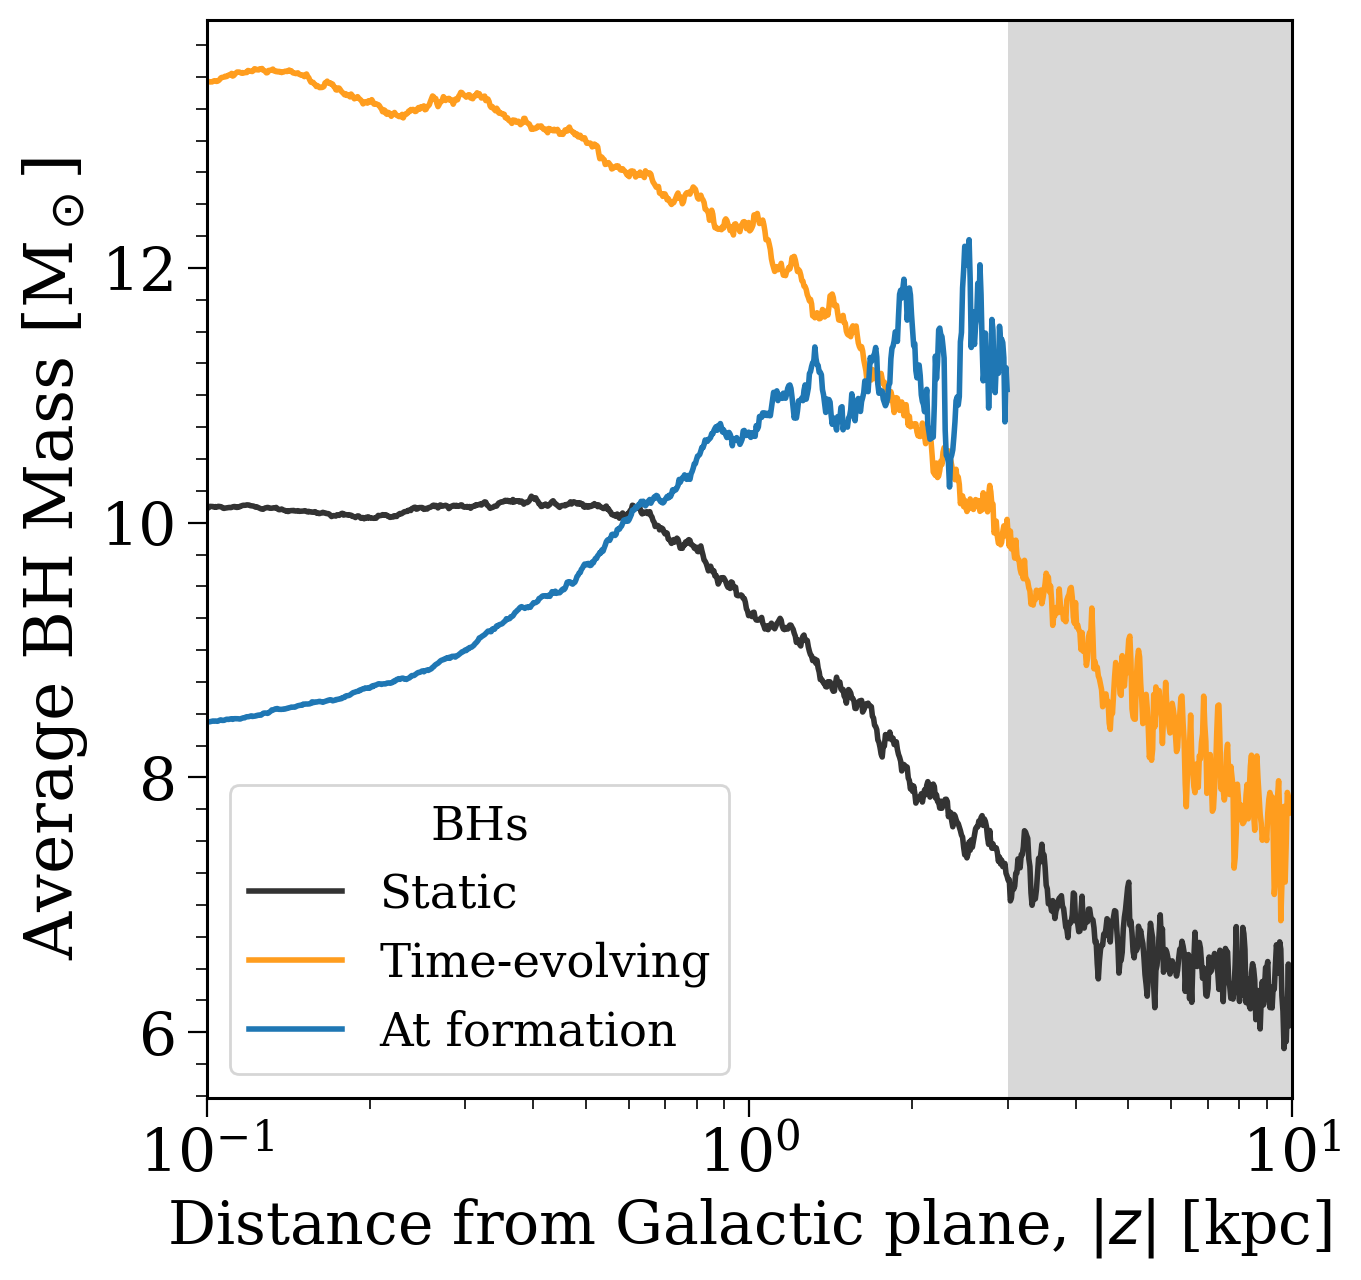

(<Figure size 700x700 with 1 Axes>,
 <Axes: xlabel='Distance from Galactic plane, $|z|$ [kpc]', ylabel='Average BH Mass [M$_\\odot$]'>)

In [15]:
plotting.plot_avg_mass_vs_z(
    mean_masses=mean_masses,
    labels=labels + ["At formation"],
    colours=colours + ["tab:blue"],
    z_maxes=[10, 10, 3],
    z_range=z_range,
)